# 실습 1: 객체 탐지 (Object Detection)

## 학습 목표
- Amazon Rekognition의 `detect_labels` API를 호출하여 이미지에서 객체를 탐지합니다.
- BoundingBox 좌표를 이해하고 이미지 위에 결과를 시각화합니다.

## API 개요
`detect_labels`는 이미지에서 객체, 장면, 활동 등을 탐지합니다.
- **MaxLabels**: 반환할 최대 레이블 수
- **MinConfidence**: 결과에 포함할 최소 신뢰도 (%)
- **반환값**: `response['Labels']` — 각 레이블에 Name, Confidence, Instances 포함


In [3]:
import boto3
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ✅ [제공 코드] Rekognition 클라이언트 초기화
rekognition = boto3.client('rekognition', region_name='ap-northeast-2')

# ✅ [제공 코드] 이미지 경로 설정
IMAGE_DIR = './images/'
image_filename = 'lab01.jpg'
image_path = os.path.join(IMAGE_DIR, image_filename)

def load_image_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

image_bytes = load_image_bytes(image_path)
print(f"이미지 경로: {image_path}")
print(f"파일 존재 여부: {os.path.exists(image_path)}")
print(f"이미지 크기: {len(image_bytes):,} bytes")

이미지 경로: ./images/lab01.jpg
파일 존재 여부: True
이미지 크기: 494,853 bytes


## ✏️ TODO 1: detect_labels API 호출

아래 빈칸을 채워 `detect_labels` API를 호출하세요.

**파라미터 안내:**
- `Image`: `{'Bytes': <이미지 바이트>}` 형식으로 전달
- `MaxLabels`: 최대 10개 레이블 탐지
- `MinConfidence`: 최소 신뢰도 70%


In [4]:
# ✏️ TODO 1: 아래 빈칸을 채우세요
response = rekognition.detect_labels( # ← detect_labels
    Image={
        'Bytes': image_bytes  # ← image_bytes
    },
    MaxLabels=10,   # ← 10
    MinConfidence=70  # ← 70
)

print("탐지된 객체 목록:")
print("-" * 40)
for label in response['Labels']:
    print(f"  {label['Name']:<25} 신뢰도: {label['Confidence']:.1f}%")

탐지된 객체 목록:
----------------------------------------
  Animal                    신뢰도: 100.0%
  Cat                       신뢰도: 100.0%
  Kitten                    신뢰도: 100.0%
  Mammal                    신뢰도: 100.0%
  Pet                       신뢰도: 100.0%


## ✏️ TODO 2: BoundingBox 시각화

탐지된 객체에 BoundingBox를 그려 이미지에 표시하세요.

**BoundingBox 구조:**
```
BoundingBox = {
    'Left':   0.0~1.0,  # 왼쪽 x 좌표 (비율)
    'Top':    0.0~1.0,  # 위쪽 y 좌표 (비율)
    'Width':  0.0~1.0,  # 너비 (비율)
    'Height': 0.0~1.0   # 높이 (비율)
}
```
실제 픽셀 좌표 = 비율 × 이미지 크기


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


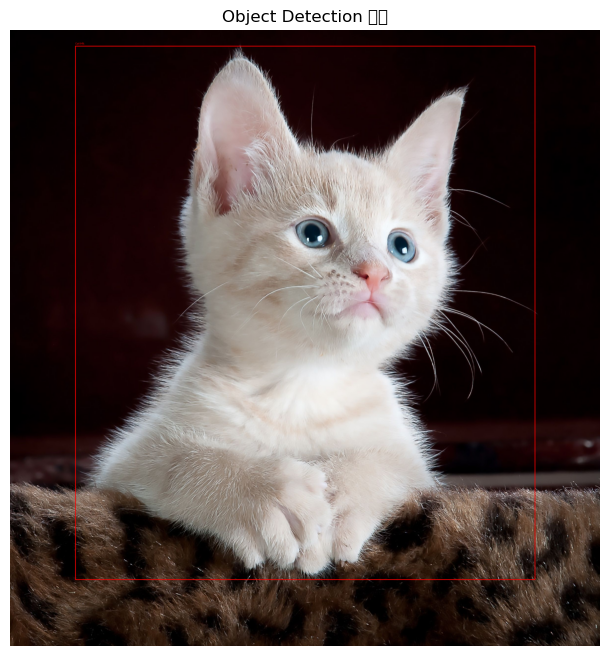

In [5]:
# ✏️ TODO 2: BoundingBox 시각화 코드를 완성하세요
img = Image.open(image_path)
draw = ImageDraw.Draw(img)
img_width, img_height = img.size

for label in response['Labels']:
    for instance in label.get('Instances', []):
        box = instance['BoundingBox']
        
        # ← 아래 빈칸: 픽셀 좌표로 변환하세요
        left   = box['Left']  * img_width   # ← img_width
        top    = box['Top']   * img_height   # ← img_height
        right  = left + box['Width']  * img_width# ← img_width
        bottom = top  + box['Height'] * img_height# ← img_height
        
        draw.rectangle([left, top, right, bottom], outline='red', width=3)
        draw.text((left, top - 15), f"{label['Name']} {instance['Confidence']:.0f}%", fill='red')

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Object Detection 결과')
plt.show()

## 💡 심화 도전
1. `MinConfidence`를 50으로 낮추면 결과가 어떻게 달라지나요?
2. `MaxLabels`를 5로 줄이면 어떤 레이블이 제외되나요?
3. Confidence가 90% 이상인 레이블만 필터링해서 출력해보세요.
